In [21]:
# =============================================================================
# 셀 1: 환경 / 경로 / 유틸
# =============================================================================
# 목적: QP2 프로젝트 SSOT 경로 로드 + 공용 유틸 함수 정의
# 산출물: 없음 (환경 세팅만)
# 주의: 02_H.ipynb 셀 1과 동일 구조
# =============================================================================

import os, warnings
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── SSOT 경로 ──
load_dotenv(Path("C:/QP2/.env"))
QP2_ROOT   = Path(os.getenv("QP2_ROOT", "C:/QP2"))
DATA_DIR   = QP2_ROOT / "data"
RAW_DIR    = DATA_DIR / "raw"
INTERIM_DIR= DATA_DIR / "interim"
META_DIR   = DATA_DIR / "meta"

# ── W-21 전용 파라미터 ──
LOOKBACK_M      = 1          # 리더 급등 판정 룩백 (월)
SURGE_SIGMA     = 1.5        # 리더 급등 기준: 섹터 평균 + N*σ
TOP_N           = 30         # 최종 매수 종목 수
COST_BP         = 20         # 편도 거래비용 (bp)
REGIME_COL      = "regime_v2"
EXCLUDE_REGIMES = ["1_Crash", "2_Recovery_Early"]

# ── 공용 유틸 ──
def winsorize(s, lower=0.01, upper=0.99):
    """시리즈 양 끝 윈저라이즈"""
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def zscore_by_date(df, col):
    """날짜별 횡단면 z-score"""
    g = df.groupby("date")[col]
    return (df[col] - g.transform("mean")) / g.transform("std")

def calc_perf(cum_ret):
    """누적수익률 시리즈 → CAGR, Sharpe, MaxDD 딕셔너리"""
    total = cum_ret.iloc[-1] / cum_ret.iloc[0]
    n_years = len(cum_ret) / 12
    cagr = total ** (1 / n_years) - 1 if n_years > 0 else 0
    monthly_ret = cum_ret.pct_change().dropna()
    sharpe = monthly_ret.mean() / monthly_ret.std() * np.sqrt(12) if monthly_ret.std() > 0 else 0
    drawdown = cum_ret / cum_ret.cummax() - 1
    maxdd = drawdown.min()
    return {"CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd}

def calc_tstat(port_ret, bm_ret):
    """포트폴리오 vs 벤치마크 월간 수익률 차이의 t-stat"""
    diff = port_ret - bm_ret
    n = len(diff)
    if n < 2 or diff.std() == 0:
        return 0.0
    return diff.mean() / diff.std() * np.sqrt(n)

VALID_REGIMES = ["4_Recovery_Late", "5_Expansion"]

print(f"QP2_ROOT: {QP2_ROOT}")
print(f"W-21 파라미터: LOOKBACK={LOOKBACK_M}M, SURGE={SURGE_SIGMA}σ, TOP_N={TOP_N}")
print("셀 1 완료")

QP2_ROOT: C:\QP2
W-21 파라미터: LOOKBACK=1M, SURGE=1.5σ, TOP_N=30
셀 1 완료


In [22]:
# =============================================================================
# 셀 2: 데이터 로드 + 섹터 매핑 + 리더 정의
# =============================================================================
# 목적: 주가/수익률/레짐/섹터 로드, 섹터별 시총 Top1을 리더로 정의
# 산출물: px_m, ret_1m, regime_m, sector_map, mktcap_m, leader_map
# 주의: 리더 = 해당 월 기준 섹터 내 시총 1위 (매월 갱신)
# =============================================================================

# ── 주가 / 수익률 ──
px_wide = pd.read_parquet(INTERIM_DIR / "yahoo_adjclose_wide.parquet")
px_wide.index = pd.to_datetime(px_wide.index)

# 월말 리샘플
px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

# 공통 종목 (NaN 과다 제거)
valid_tickers = ret_1m.columns[ret_1m.notna().sum() > len(ret_1m) * 0.5]
ret_1m = ret_1m[valid_tickers]
px_m = px_m[valid_tickers]

# EW 벤치마크
ew_ret = ret_1m.mean(axis=1)

# ── 레짐 ──
regime_all = pd.read_parquet(INTERIM_DIR / "regime_indicators_combined.parquet")
regime_all.index = pd.to_datetime(regime_all.index)
regime_m = regime_all[REGIME_COL].resample("ME").last().ffill()

# ── 섹터 매핑 ──
universe = pd.read_parquet(META_DIR / "sp500_universe.parquet")
sector_map = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ret_1m에 있는 종목만 필터
sector_map = {t: s for t, s in sector_map.items() if t in ret_1m.columns}
print(f"섹터 매핑 종목 수: {len(sector_map)}")
print(f"섹터 수: {len(set(sector_map.values()))}")

# ── 시가총액 ──
mktcap_m = pd.read_parquet(INTERIM_DIR / "mktcap_monthly.parquet")
mktcap_m.index = pd.to_datetime(mktcap_m.index)

# ── 섹터별 리더 정의 (매월, 시총 1위) ──
# 리더는 매월 바뀔 수 있음 (ex: 2020년 AAPL → 2024년 NVDA 등)
sectors = set(sector_map.values())
ticker_to_sector = pd.Series(sector_map)
ticker_to_sector_s = ticker_to_sector  # 이후 셀 호환용

leader_records = []
for date in mktcap_m.index:
    row = mktcap_m.loc[date].dropna()
    for sect in sectors:
        sect_tickers = ticker_to_sector[ticker_to_sector == sect].index
        sect_tickers = sect_tickers.intersection(row.index)
        if len(sect_tickers) == 0:
            continue
        sect_caps = row[sect_tickers]
        leader = sect_caps.idxmax()
        leader_records.append({
            "date": date,
            "sector": sect,
            "leader": leader,
            "leader_mktcap": sect_caps[leader]
        })

leader_map = pd.DataFrame(leader_records)
print(f"\n리더 매핑: {len(leader_map)} rows, "
      f"기간 {leader_map['date'].min().strftime('%Y-%m')} ~ "
      f"{leader_map['date'].max().strftime('%Y-%m')}")

# 리더 분포 확인 (최근 날짜 기준)
latest = leader_map[leader_map["date"] == leader_map["date"].max()]
print(f"\n최근 리더 ({latest['date'].iloc[0].strftime('%Y-%m')}):")
for _, r in latest.sort_values("sector").iterrows():
    print(f"  {r['sector']:30s} → {r['leader']}")


# ── 레짐 매핑 함수 ──
def get_regime_for_date(date):
    idx = regime_m.index[regime_m.index <= date]
    if len(idx) == 0:
        return "UNKNOWN"
    return regime_m.loc[idx[-1]]

print("\n셀 2 완료")

섹터 매핑 종목 수: 277
섹터 수: 11

리더 매핑: 2255 rows, 기간 2009-01 ~ 2026-01

최근 리더 (2026-01):
  Communication Services         → DIS
  Consumer Discretionary         → HD
  Consumer Staples               → WMT
  Energy                         → XOM
  Financials                     → JPM
  Health Care                    → LLY
  Industrials                    → CAT
  Information Technology         → AAPL
  Materials                      → LIN
  Real Estate                    → WELL
  Utilities                      → NEE

셀 2 완료


In [23]:
# =============================================================================
# 셀 3-r: 일간 기반 리더 급등 감지 + 후발 시그널 생성
# =============================================================================
# 목적: 일간 수익률 기준 리더 급등 이벤트 감지, 후발주 시그널 생성
# 산출물: w21_daily_signal (date, ticker, sector, w21_raw, w21_z)
# 주의:
#   - 리더 급등 = 당일 리더 수익률 > 섹터평균 + SURGE_SIGMA * 섹터std(20일 롤링)
#   - 후발주 = 같은 섹터, 당일 수익률 < 섹터 중앙값
#   - 리더: 월별 시총 Top1 (월초 기준, 매일 바꾸진 않음)
# =============================================================================

from tqdm import tqdm

# ── 일간 수익률 ──
ret_1d = px_wide.pct_change()
common_tickers = ret_1d.columns.intersection(ticker_to_sector_s.index)
ret_1d = ret_1d[common_tickers]

# ── 리더 매핑을 일간으로 확장 (월초 기준 고정) ──
# leader_map은 월말 date 기준 → 해당 월 전체에 적용
leader_daily = {}
for _, row in leader_map.iterrows():
    # 해당 월의 모든 거래일에 리더 매핑
    ym = row["date"].strftime("%Y-%m")
    leader_daily[(ym, row["sector"])] = row["leader"]

# ── 섹터별 20일 롤링 σ 계산 ──
# 섹터 평균 일간 수익률의 롤링 std
sectors_list = sorted(set(ticker_to_sector_s.values))

# 섹터별 일간 평균 수익률
sect_ret_daily = {}
for sect in sectors_list:
    tks = ticker_to_sector_s[ticker_to_sector_s == sect].index
    tks = tks.intersection(ret_1d.columns)
    if len(tks) > 0:
        sect_ret_daily[sect] = ret_1d[tks].mean(axis=1)

sect_ret_df = pd.DataFrame(sect_ret_daily)
sect_roll_std = sect_ret_df.rolling(20, min_periods=10).std()

# ── 시그널 생성 ──
SURGE_SIGMA_D = 2.0  # 일간은 좀 더 높은 기준

# 분석 기간 제한 (2013-06 이후, 데이터 안정 구간)
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d.index[ret_1d.index >= start_date]

records = []

for date in tqdm(trading_days, desc="W-21 daily signal"):
    ym = date.strftime("%Y-%m")
    day_ret = ret_1d.loc[date].dropna()
    
    if date not in sect_roll_std.index:
        continue
    
    for sect in sectors_list:
        # 리더 찾기
        key = (ym, sect)
        if key not in leader_daily:
            continue
        leader = leader_daily[key]
        
        # 섹터 종목
        sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
        sect_tickers = sect_tickers.intersection(day_ret.index)
        if len(sect_tickers) < 5 or leader not in day_ret.index:
            continue
        
        sect_ret = day_ret[sect_tickers]
        leader_ret = sect_ret[leader]
        sect_mean = sect_ret.mean()
        
        # 롤링 σ
        roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
        if roll_s is None or pd.isna(roll_s) or roll_s == 0:
            continue
        
        # ── 리더 급등 판정 ──
        if leader_ret <= sect_mean + SURGE_SIGMA_D * roll_s:
            continue
        
        # ── 후발주: 당일 섹터 중앙값 미만 ──
        sect_median = sect_ret.median()
        non_leader = sect_ret.drop(leader, errors="ignore")
        laggards = non_leader[non_leader < sect_median]
        
        for ticker in laggards.index:
            gap = sect_median - sect_ret[ticker]
            records.append({
                "date": date,
                "ticker": ticker,
                "sector": sect,
                "leader": leader,
                "leader_ret": leader_ret,
                "ticker_ret": sect_ret[ticker],
                "w21_raw": gap
            })

w21_daily = pd.DataFrame(records)

if len(w21_daily) > 0:
    w21_daily["w21_z"] = zscore_by_date(w21_daily, "w21_raw")

print(f"\nW-21 일간 시그널 생성 완료")
print(f"  총 rows: {len(w21_daily):,}")
print(f"  기간: {w21_daily['date'].min().strftime('%Y-%m-%d')} ~ "
      f"{w21_daily['date'].max().strftime('%Y-%m-%d')}")
print(f"  이벤트 발생일 수: {w21_daily['date'].nunique():,}")
print(f"  전체 거래일 대비: {w21_daily['date'].nunique() / len(trading_days) * 100:.1f}%")
print(f"  고유 종목 수: {w21_daily['ticker'].nunique()}")
print(f"\n이벤트 빈도:")
events_per_day = w21_daily.groupby('date')['sector'].nunique()
print(f"  이벤트일 평균: {events_per_day.mean():.1f} 섹터/일")
picks_per_day = w21_daily.groupby('date').size()
print(f"  이벤트일 평균 후보 종목: {picks_per_day.mean():.1f}")

print("\n셀 3-r 완료")

W-21 daily signal: 100%|██████████| 3178/3178 [00:38<00:00, 83.20it/s]


W-21 일간 시그널 생성 완료
  총 rows: 13,688
  기간: 2013-07-19 ~ 2026-01-30
  이벤트 발생일 수: 804
  전체 거래일 대비: 25.3%
  고유 종목 수: 276

이벤트 빈도:
  이벤트일 평균: 1.2 섹터/일
  이벤트일 평균 후보 종목: 17.0

셀 3-r 완료


In [24]:
# =============================================================================
# 셀 5: H팩터 상관관계 분석 + 잔차 알파 테스트
# =============================================================================
# 목적: W-21 시그널에서 H팩터로 설명되는 부분을 제거하고,
#        잔차(순수 leader-laggard 효과)만으로 알파 유무 확인
# 산출물: W-21 raw vs H 상관, 잔차 백테스트 결과
# 주의:
#   - H = 섹터 3M 모멘텀 z-score (02_H.ipynb 동일 로직)
#   - 잔차 = W-21_z - β * H_z (횡단면 회귀 잔차)
# =============================================================================

# ── H 시그널 재생성 (3M 섹터 모멘텀 → 종목 레벨 z-score) ──
H_LOOKBACK = 3  # 02_H.ipynb 확정 파라미터

# 월간 섹터 EW 수익률
sect_ret_monthly = {}
for sect in sectors_list:
    tks = ticker_to_sector_s[ticker_to_sector_s == sect].index
    tks = tks.intersection(ret_1m.columns)
    if len(tks) > 0:
        sect_ret_monthly[sect] = ret_1m[tks].mean(axis=1)

sect_ret_m_df = pd.DataFrame(sect_ret_monthly)

# 3M 롤링 섹터 모멘텀
sect_mom_3m = sect_ret_m_df.rolling(H_LOOKBACK).sum()

# 섹터 모멘텀 → 횡단면 z-score (섹터 레벨)
def sect_zscore(row):
    m, s = row.mean(), row.std()
    return (row - m) / s if s > 0 else row * 0

sect_mom_z = sect_mom_3m.apply(sect_zscore, axis=1)

# 종목 레벨 H-score: 해당 종목의 섹터 z-score를 매핑
# 일간으로 확장 (월말 기준 → 해당 월 전체 적용)
h_monthly = {}
for date in sect_mom_z.index:
    if pd.isna(sect_mom_z.loc[date]).all():
        continue
    for ticker in ticker_to_sector_s.index:
        sect = ticker_to_sector_s[ticker]
        if sect in sect_mom_z.columns and not pd.isna(sect_mom_z.loc[date, sect]):
            h_monthly[(date, ticker)] = sect_mom_z.loc[date, sect]

h_score_monthly = pd.Series(h_monthly)
h_score_monthly.index = pd.MultiIndex.from_tuples(h_score_monthly.index, names=["date_m", "ticker"])
h_score_monthly = h_score_monthly.reset_index()
h_score_monthly.columns = ["date_m", "ticker", "h_z"]

# ── W-21 이벤트에 H-score 매칭 ──
# W-21 이벤트의 date → 해당 월말로 매핑해서 H-score 결합
w21_daily["date_m"] = w21_daily["date"].dt.to_period("M").dt.to_timestamp("M")

w21_h = w21_daily.merge(h_score_monthly, on=["date_m", "ticker"], how="left")

valid_both = w21_h.dropna(subset=["w21_z", "h_z"])
print(f"W-21 × H 매칭: {len(valid_both):,} / {len(w21_daily):,} rows")

# ── 상관관계 ──
corr = valid_both["w21_z"].corr(valid_both["h_z"])
print(f"\nW-21 vs H 신호 상관계수: {corr:.4f}")

# ── 횡단면 회귀로 잔차 추출 ──
# 날짜별 W-21_z = α + β*H_z + ε
# ε = W-21의 순수 leader-laggard 효과
from numpy.linalg import lstsq

residuals = []
dates_with_data = valid_both["date"].unique()

for date in dates_with_data:
    chunk = valid_both[valid_both["date"] == date]
    if len(chunk) < 5:
        continue
    
    y = chunk["w21_z"].values
    X = np.column_stack([np.ones(len(chunk)), chunk["h_z"].values])
    
    coef, _, _, _ = lstsq(X, y, rcond=None)
    resid = y - X @ coef
    
    for i, (_, row) in enumerate(chunk.iterrows()):
        residuals.append({
            "date": date,
            "ticker": row["ticker"],
            "sector": row["sector"],
            "w21_z": row["w21_z"],
            "h_z": row["h_z"],
            "w21_resid": resid[i]
        })

w21_resid = pd.DataFrame(residuals)
print(f"잔차 추출 완료: {len(w21_resid):,} rows")

# ── 잔차 기반 백테스트 (20d, Top20) vs Raw 비교 ──
def backtest_signal_col(signal_df, score_col, px_wide, hold_days=20, top_n=20, cost_bp=20):
    """범용 이벤트 백테스트 — score_col 기준 top_n 선정"""
    cost = cost_bp / 10000 * 2
    trade_records = []
    event_dates = sorted(signal_df["date"].unique())
    all_dates = px_wide.index.sort_values()
    
    for edate in event_dates:
        future = all_dates[all_dates > edate]
        if len(future) < hold_days + 1:
            continue
        entry_date = future[0]
        exit_date = future[hold_days]
        
        ev_sig = signal_df[signal_df["date"] == edate].nlargest(top_n, score_col)
        picks = [t for t in ev_sig["ticker"].values if t in px_wide.columns]
        
        if len(picks) < 3:
            continue
        
        entry_p = px_wide.loc[entry_date, picks]
        exit_p = px_wide.loc[exit_date, picks]
        valid = entry_p.notna() & exit_p.notna() & (entry_p > 0)
        
        if valid.sum() < 3:
            continue
        
        rets = exit_p[valid] / entry_p[valid] - 1
        trade_records.append({
            "entry": entry_date,
            "exit": exit_date,
            "n_stocks": int(valid.sum()),
            "net_ret": rets.mean() - cost
        })
    
    return pd.DataFrame(trade_records)

# Raw W-21
bt_raw = backtest_signal_col(w21_resid, "w21_z", px_wide, 20, 20)
# 잔차 기반
bt_resid = backtest_signal_col(w21_resid, "w21_resid", px_wide, 20, 20)

def summarize(bt, label):
    if bt.empty:
        return {}
    n = len(bt)
    avg = bt["net_ret"].mean()
    t = avg / bt["net_ret"].std() * np.sqrt(n) if bt["net_ret"].std() > 0 else 0
    hit = (bt["net_ret"] > 0).mean()
    return {
        "Version": label,
        "Trades": n,
        "Avg_Ret%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    }

comp = pd.DataFrame([
    summarize(bt_raw, "W-21 Raw"),
    summarize(bt_resid, "W-21 Residual (H 제거)")
])

print("\n" + "="*70)
print("W-21 vs W-21 잔차 (H 영향 제거) 비교")
print("="*70)
print(comp.to_string(index=False))

# ── 포트폴리오 겹침률 ──
overlap_records = []
for date in dates_with_data:
    raw_top = w21_resid[w21_resid["date"] == date].nlargest(20, "w21_z")["ticker"].values
    res_top = w21_resid[w21_resid["date"] == date].nlargest(20, "w21_resid")["ticker"].values
    if len(raw_top) > 0 and len(res_top) > 0:
        overlap = len(set(raw_top) & set(res_top)) / max(len(raw_top), len(res_top))
        overlap_records.append(overlap)

avg_overlap = np.mean(overlap_records) if overlap_records else 0
print(f"\nRaw vs Residual 포트폴리오 평균 겹침률: {avg_overlap*100:.1f}%")

print("\n셀 5 완료")

W-21 × H 매칭: 13,688 / 13,688 rows

W-21 vs H 신호 상관계수: -0.0044
잔차 추출 완료: 13,403 rows

W-21 vs W-21 잔차 (H 영향 제거) 비교
             Version  Trades  Avg_Ret%  Hit%  t_stat
            W-21 Raw     702     0.588  57.0   3.107
W-21 Residual (H 제거)     702     0.566  56.8   2.991

Raw vs Residual 포트폴리오 평균 겹침률: 98.5%

셀 5 완료


In [25]:
# =============================================================================
# 셀 15: Gross 수익률 비교 (비용 제거)
# =============================================================================
# 목적: 거래비용 제거하고 순수 tier별 초과수익 확인
#        기존 결과가 비용 왜곡인지, 진짜 무알파인지 판별
# 산출물: 보유기간 × tier gross 초과수익
# =============================================================================

from tqdm import tqdm

def backtest_gross(px_wide, mktcap_m, ticker_to_sector_s,
                    sect_roll_std, sect_mom_z, sectors_list,
                    hold_days=20, surge_sigma=2.0,
                    valid_regimes=None, h_min_z=0.0):
    all_dates = px_wide.index.sort_values()
    ret_1d_local = px_wide.pct_change()
    common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
    ret_1d_local = ret_1d_local[common]
    
    start_date = pd.Timestamp("2013-06-19")
    trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]
    
    trades = []
    
    for date in trading_days:
        if valid_regimes:
            reg = get_regime_for_date(date)
            if reg not in valid_regimes:
                continue
        
        day_ret = ret_1d_local.loc[date].dropna()
        if date not in sect_roll_std.index:
            continue
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            if h_row[sect] < h_min_z:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + surge_sigma * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < hold_days + 2:
                continue
            entry_date = future[1]
            exit_date = future[1 + hold_days]
            
            # 시총 tier
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q25 = non_leader_caps.quantile(0.25)
            q75 = non_leader_caps.quantile(0.75)
            
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            middle = non_leader_caps[(non_leader_caps >= q25) & (non_leader_caps < q75)].index.tolist()
            laggard = non_leader_caps[non_leader_caps < q25].index.tolist()
            
            def tier_ret_gross(picks):
                picks = [t for t in picks if t in px_wide.columns]
                if len(picks) < 1:
                    return np.nan
                ep = px_wide.loc[entry_date, picks]
                xp = px_wide.loc[exit_date, picks]
                v = ep.notna() & xp.notna() & (ep > 0)
                if v.sum() < 1:
                    return np.nan
                return (xp[v] / ep[v] - 1).mean()  # NO COST
            
            # 섹터 EW (리더 포함, NO COST)
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            sect_ep = px_wide.loc[entry_date, sect_all]
            sect_xp = px_wide.loc[exit_date, sect_all]
            sv = sect_ep.notna() & sect_xp.notna() & (sect_ep > 0)
            sect_ew = (sect_xp[sv] / sect_ep[sv] - 1).mean() if sv.sum() > 3 else np.nan
            
            trades.append({
                "date": date,
                "sector": sect,
                "leader_ret": tier_ret_gross([leader]),
                "top_ret": tier_ret_gross(top_tier),
                "mid_ret": tier_ret_gross(middle),
                "lag_ret": tier_ret_gross(laggard),
                "sect_ew": sect_ew
            })
    
    return pd.DataFrame(trades)


# ── 보유기간 민감도 (gross) ──
hold_range = [5, 10, 15, 20, 30, 40, 60]
all_results = []

for hold in tqdm(hold_range, desc="Gross 민감도"):
    bt = backtest_gross(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=hold, surge_sigma=2.0,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    bt = bt.dropna(subset=["mid_ret", "sect_ew"])
    
    for col, label in [("leader_ret", "Leader"),
                       ("top_ret", "Top(Q4)"),
                       ("mid_ret", "Mid(Q2-Q3)"),
                       ("lag_ret", "Lag(Q1)")]:
        excess = (bt[col] - bt["sect_ew"]).dropna()
        n = len(excess)
        if n < 5:
            continue
        avg = excess.mean()
        t = avg / excess.std() * np.sqrt(n) if excess.std() > 0 else 0
        hit = (excess > 0).mean()
        
        all_results.append({
            "Hold": f"{hold}d",
            "Tier": label,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(all_results)

print("=" * 80)
print("GROSS 수익률 — 시총Tier vs SectorEW (비용 없음)")
print("H유효 섹터, Recovery_Late + Expansion, 다음날 진입")
print("=" * 80)

for tier in ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]:
    sub = res_df[res_df["Tier"] == tier]
    print(f"\n--- {tier} ---")
    print(sub[["Hold", "N", "Excess%", "Hit%", "t_stat"]].to_string(index=False))

print("\n셀 15 완료")

Gross 민감도:  71%|███████▏  | 5/7 [02:37<01:03, 31.54s/it]


KeyboardInterrupt: 

초단기 Gross: 100%|██████████| 8/8 [03:38<00:00, 27.36s/it]


GROSS 초단기 — 시총Tier vs SectorEW
H유효 섹터, Recovery_Late + Expansion, 다음날 진입

--- Leader ---
Hold   N  Excess%  Hit%  t_stat
  1d 369    0.015  48.5   0.203
  2d 369   -0.002  47.4  -0.017
  3d 369    0.004  49.9   0.032
  5d 369   -0.037  49.3  -0.206
  7d 369   -0.108  47.4  -0.534
 10d 369   -0.243  47.2  -1.048
 15d 369   -0.216  45.8  -0.741
 20d 367   -0.400  46.6  -1.176

--- Top(Q4) ---
Hold   N  Excess%  Hit%  t_stat
  1d 369    0.013  53.1   0.603
  2d 369    0.041  53.7   1.286
  3d 369    0.057  56.9   1.445
  5d 369    0.078  54.2   1.516
  7d 369    0.104  55.3   1.822
 10d 369    0.053  52.3   0.772
 15d 369    0.008  50.7   0.096
 20d 367    0.027  52.3   0.285

--- Mid(Q2-Q3) ---
Hold   N  Excess%  Hit%  t_stat
  1d 369   -0.003  50.9  -0.222
  2d 369   -0.025  46.1  -1.253
  3d 369   -0.032  48.5  -1.286
  5d 369   -0.020  47.2  -0.619
  7d 369    0.000  50.1   0.005
 10d 369    0.038  51.2   0.879
 15d 369    0.048  54.7   0.882
 20d 367    0.028  52.9   0.472

--- Lag(Q

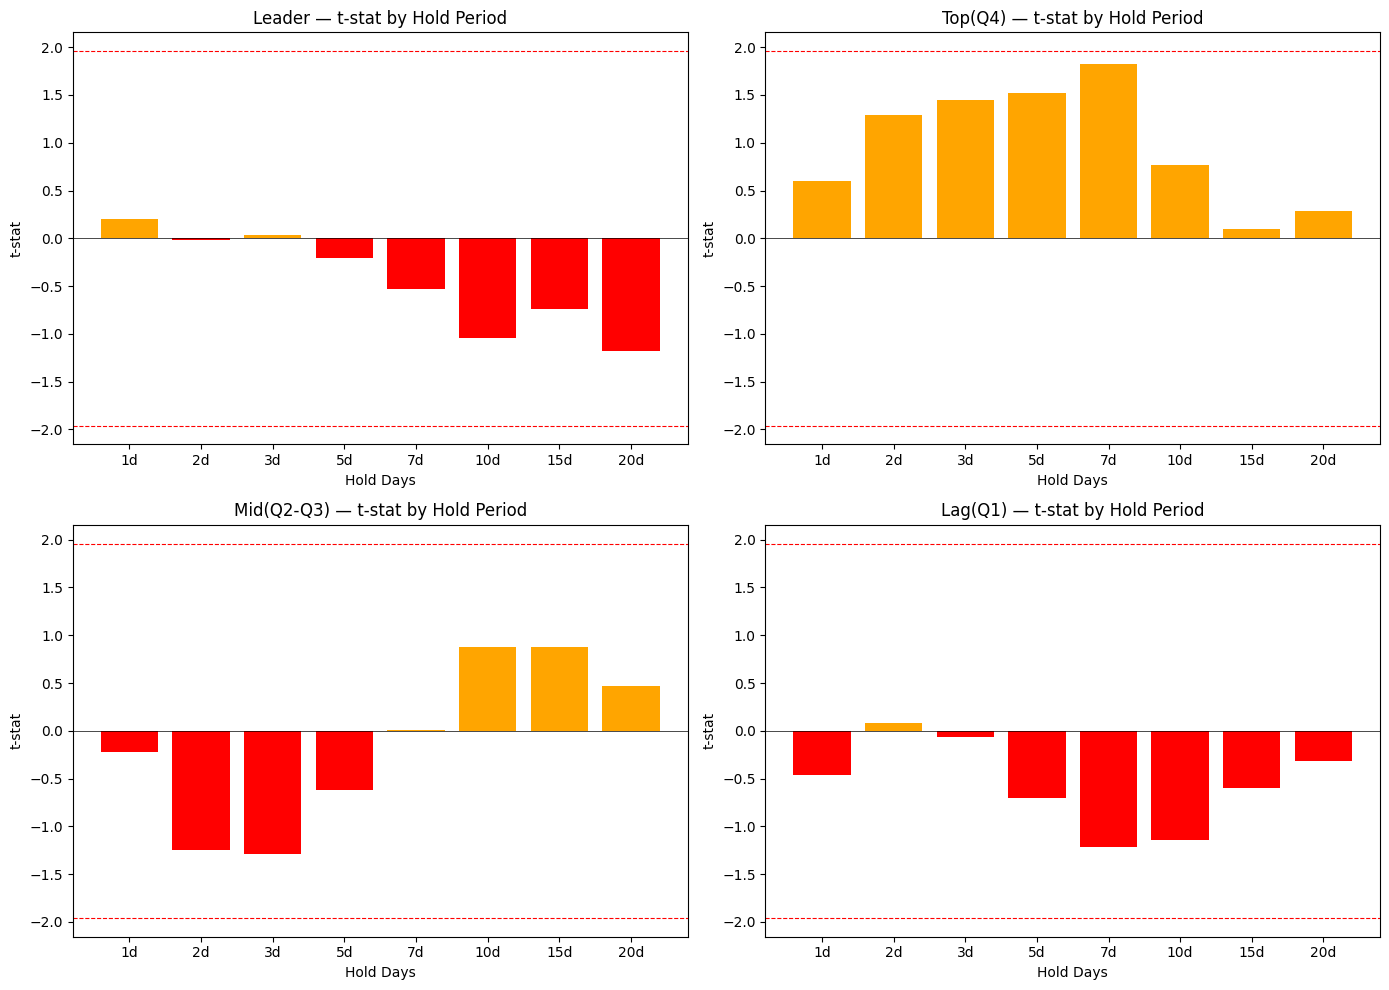


셀 16 완료


In [ ]:
# =============================================================================
# 셀 16: 초단기 보유 추가 (1d, 3d) — Gross
# =============================================================================
# 목적: 1d, 3d 보유에서 tier별 초과수익 확인
#        스필오버가 초단기에 발생하는지 검증
# 산출물: 1d~20d 전체 비교표
# =============================================================================

from tqdm import tqdm

hold_range_short = [1, 2, 3, 5, 7, 10, 15, 20]
all_results = []

for hold in tqdm(hold_range_short, desc="초단기 Gross"):
    bt = backtest_gross(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=hold, surge_sigma=2.0,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    bt = bt.dropna(subset=["mid_ret", "sect_ew"])
    
    for col, label in [("leader_ret", "Leader"),
                       ("top_ret", "Top(Q4)"),
                       ("mid_ret", "Mid(Q2-Q3)"),
                       ("lag_ret", "Lag(Q1)")]:
        excess = (bt[col] - bt["sect_ew"]).dropna()
        n = len(excess)
        if n < 5:
            continue
        avg = excess.mean()
        t = avg / excess.std() * np.sqrt(n) if excess.std() > 0 else 0
        hit = (excess > 0).mean()
        
        all_results.append({
            "Hold": hold,
            "Tier": label,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(all_results)

print("=" * 80)
print("GROSS 초단기 — 시총Tier vs SectorEW")
print("H유효 섹터, Recovery_Late + Expansion, 다음날 진입")
print("=" * 80)

for tier in ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]:
    sub = res_df[res_df["Tier"] == tier].copy()
    print(f"\n--- {tier} ---")
    sub["Hold"] = sub["Hold"].astype(str) + "d"
    print(sub[["Hold", "N", "Excess%", "Hit%", "t_stat"]].to_string(index=False))

# ── 전 tier 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tier_list = ["Leader", "Top(Q4)", "Mid(Q2-Q3)", "Lag(Q1)"]

for ax, tier in zip(axes.flat, tier_list):
    sub = res_df[res_df["Tier"] == tier].copy()
    if sub.empty:
        continue
    sub["t_stat"] = sub["t_stat"].astype(float)
    colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
              for t in sub["t_stat"]]
    ax.bar(range(len(sub)), sub["t_stat"].values, color=colors,
           tick_label=[f"{h}d" for h in sub["Hold"].values])
    ax.axhline(1.96, color="red", linewidth=0.8, linestyle="--")
    ax.axhline(-1.96, color="red", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{tier} — t-stat by Hold Period")
    ax.set_xlabel("Hold Days")
    ax.set_ylabel("t-stat")

plt.tight_layout()
plt.show()

print("\n셀 16 완료")

σ 민감도: 100%|██████████| 9/9 [04:43<00:00, 31.47s/it]


σ 민감도 — Top(Q4) × 7d hold, Gross, H유효+RecLate+Expansion
   σ  Events  Event_days  Excess%  Hit%  t_stat
0.50    2939        1632   -0.037  50.5  -1.727
0.75    1978        1281   -0.023  50.8  -0.891
1.00    1385        1011   -0.009  50.8  -0.293
1.25     962         774    0.011  51.9   0.293
1.50     691         592    0.015  51.8   0.339
1.75     515         459    0.060  54.0   1.165
2.00     369         343    0.104  55.3   1.822
2.50     231         220    0.185  56.7   2.502
3.00     139         134    0.294  62.6   3.024


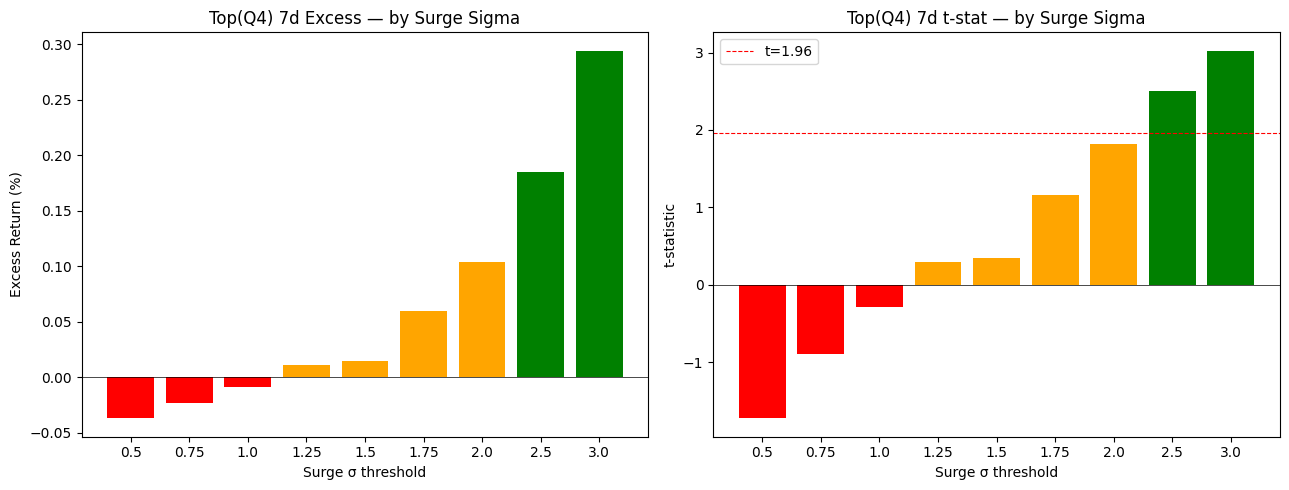


셀 17 완료


In [ ]:
# =============================================================================
# 셀 17: σ 민감도 — Top(Q4) × 7d 고정
# =============================================================================
# 목적: σ를 낮춰 이벤트 수 늘렸을 때 Top Q4 7d 알파가 유지되는지
# 산출물: σ별 성과 비교표
# 주의: σ 낮추면 이벤트 늘지만 시그널 품질 떨어질 수 있음
# =============================================================================

from tqdm import tqdm

def backtest_gross_single(px_wide, mktcap_m, ticker_to_sector_s,
                           sect_roll_std, sect_mom_z, sectors_list,
                           hold_days=7, surge_sigma=2.0,
                           valid_regimes=None, h_min_z=0.0):
    """Top Q4만 리턴하는 경량 버전"""
    all_dates = px_wide.index.sort_values()
    ret_1d_local = px_wide.pct_change()
    common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
    ret_1d_local = ret_1d_local[common]
    
    start_date = pd.Timestamp("2013-06-19")
    trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]
    
    trades = []
    
    for date in trading_days:
        if valid_regimes:
            reg = get_regime_for_date(date)
            if reg not in valid_regimes:
                continue
        
        day_ret = ret_1d_local.loc[date].dropna()
        if date not in sect_roll_std.index:
            continue
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            if h_row[sect] < h_min_z:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + surge_sigma * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < hold_days + 2:
                continue
            entry_date = future[1]
            exit_date = future[1 + hold_days]
            
            # Top Q4만
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q75 = non_leader_caps.quantile(0.75)
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            top_tier = [t for t in top_tier if t in px_wide.columns]
            
            if len(top_tier) < 1:
                continue
            
            ep = px_wide.loc[entry_date, top_tier]
            xp = px_wide.loc[exit_date, top_tier]
            v = ep.notna() & xp.notna() & (ep > 0)
            if v.sum() < 1:
                continue
            top_ret = (xp[v] / ep[v] - 1).mean()
            
            # 섹터 EW
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            sect_ep = px_wide.loc[entry_date, sect_all]
            sect_xp = px_wide.loc[exit_date, sect_all]
            sv = sect_ep.notna() & sect_xp.notna() & (sect_ep > 0)
            sect_ew = (sect_xp[sv] / sect_ep[sv] - 1).mean() if sv.sum() > 3 else np.nan
            
            if pd.isna(sect_ew):
                continue
            
            trades.append({
                "date": date,
                "sector": sect,
                "top_ret": top_ret,
                "sect_ew": sect_ew,
                "excess": top_ret - sect_ew
            })
    
    return pd.DataFrame(trades)


# ── σ 범위 ──
sigma_range = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]

results = []

for sig in tqdm(sigma_range, desc="σ 민감도"):
    bt = backtest_gross_single(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=7, surge_sigma=sig,
        valid_regimes=VALID_REGIMES, h_min_z=0.0
    )
    
    if bt.empty:
        continue
    
    n = len(bt)
    avg = bt["excess"].mean()
    std = bt["excess"].std()
    t = avg / std * np.sqrt(n) if std > 0 else 0
    hit = (bt["excess"] > 0).mean()
    events_days = bt["date"].nunique()
    
    results.append({
        "σ": sig,
        "Events": n,
        "Event_days": events_days,
        "Excess%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    })

sig_df = pd.DataFrame(results)

print("=" * 80)
print("σ 민감도 — Top(Q4) × 7d hold, Gross, H유효+RecLate+Expansion")
print("=" * 80)
print(sig_df.to_string(index=False))

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
          for t in sig_df["t_stat"]]

axes[0].bar(range(len(sig_df)), sig_df["Excess%"].values, color=colors,
            tick_label=[str(s) for s in sig_df["σ"].values])
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Surge σ threshold")
axes[0].set_ylabel("Excess Return (%)")
axes[0].set_title("Top(Q4) 7d Excess — by Surge Sigma")

axes[1].bar(range(len(sig_df)), sig_df["t_stat"].values, color=colors,
            tick_label=[str(s) for s in sig_df["σ"].values])
axes[1].axhline(1.96, color="red", linewidth=0.8, linestyle="--", label="t=1.96")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Surge σ threshold")
axes[1].set_ylabel("t-statistic")
axes[1].set_title("Top(Q4) 7d t-stat — by Surge Sigma")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n셀 17 완료")

σ sweep (최적화): 100%|██████████| 7/7 [04:06<00:00, 35.25s/it]


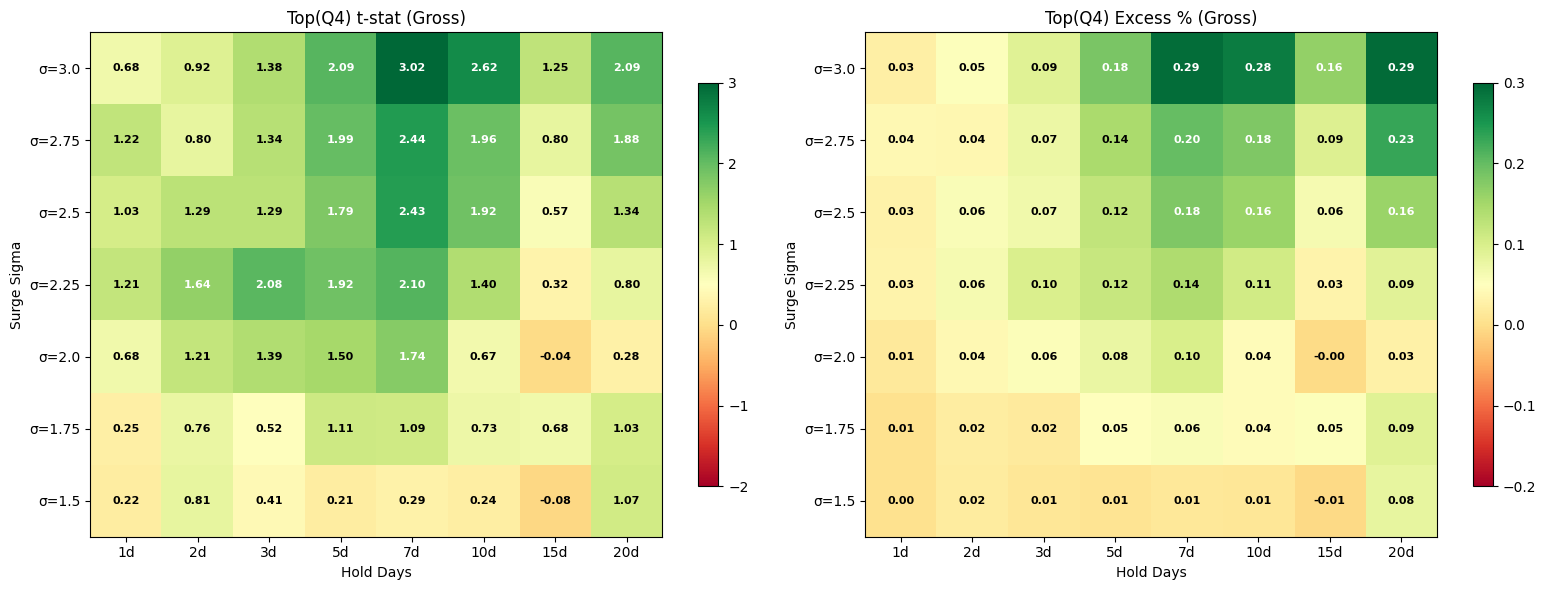


2D Sweep — Top(Q4) Gross, H유효+RecLate+Expansion

t-stat:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  0.678  0.918  1.384  2.092  3.024  2.616  1.246  2.093
2.75  1.223  0.802  1.336  1.987  2.437  1.957  0.801  1.875
2.50  1.029  1.291  1.290  1.794  2.429  1.923  0.575  1.339
2.25  1.214  1.636  2.076  1.918  2.102  1.395  0.317  0.795
2.00  0.677  1.212  1.386  1.496  1.735  0.665 -0.045  0.285
1.75  0.253  0.755  0.516  1.106  1.093  0.726  0.679  1.034
1.50  0.220  0.812  0.414  0.209  0.289  0.237 -0.084  1.072

Excess%:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  0.026  0.052  0.091  0.184  0.294  0.277  0.164  0.295
2.75  0.039  0.038  0.074  0.144  0.199  0.180  0.093  0.231
2.50  0.029  0.056  0.068  0.123  0.180  0.158  0.063  0.159
2.25  0.031  0.062  0.098  0.117  0.141  0.108  0.032  0.088
2.00  0.015  0.03

In [ ]:
# =============================================================================
# 셀 18: σ × Hold 2D 민감도 — Top(Q4) Gross (최적화)
# =============================================================================
# 목적: σ별로 이벤트 1번만 감지, 보유기간은 수익률만 재계산
# 산출물: 히트맵 (Excess%, t-stat)
# 최적화: σ당 1회 루프, hold는 벡터 계산
# =============================================================================

from tqdm import tqdm

sigma_range = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
hold_range = [1, 2, 3, 5, 7, 10, 15, 20]
max_hold = max(hold_range)

all_dates = px_wide.index.sort_values()
ret_1d_local = px_wide.pct_change()
common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
ret_1d_local = ret_1d_local[common]
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]

results = []

for sig in tqdm(sigma_range, desc="σ sweep (최적화)"):
    # ── 이벤트 감지 + 모든 hold 수익률 한번에 ──
    events = []
    
    for date in trading_days:
        reg = get_regime_for_date(date)
        if reg not in VALID_REGIMES:
            continue
        
        if date not in sect_roll_std.index:
            continue
        day_ret = ret_1d_local.loc[date].dropna()
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]) or h_row[sect] < 0.0:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + sig * roll_s:
                continue
            
            # 이벤트 감지됨 — 모든 hold 수익률 계산
            future = all_dates[all_dates > date]
            if len(future) < max_hold + 2:
                continue
            entry_date = future[1]
            
            # Top Q4
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q75 = non_leader_caps.quantile(0.75)
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            top_tier = [t for t in top_tier if t in px_wide.columns]
            if len(top_tier) < 1:
                continue
            
            ep_top = px_wide.loc[entry_date, top_tier]
            
            # 섹터 EW
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            ep_sect = px_wide.loc[entry_date, sect_all]
            
            evt = {"date": date, "sector": sect}
            
            for hold in hold_range:
                exit_date = future[1 + hold] if len(future) > 1 + hold else None
                if exit_date is None:
                    continue
                
                # Top Q4 수익률
                xp_top = px_wide.loc[exit_date, top_tier]
                v = ep_top.notna() & xp_top.notna() & (ep_top > 0)
                top_ret = (xp_top[v] / ep_top[v] - 1).mean() if v.sum() > 0 else np.nan
                
                # Sect EW
                xp_sect = px_wide.loc[exit_date, sect_all]
                sv = ep_sect.notna() & xp_sect.notna() & (ep_sect > 0)
                sect_ew = (xp_sect[sv] / ep_sect[sv] - 1).mean() if sv.sum() > 3 else np.nan
                
                evt[f"excess_{hold}d"] = top_ret - sect_ew if not (pd.isna(top_ret) or pd.isna(sect_ew)) else np.nan
            
            events.append(evt)
    
    if not events:
        continue
    
    evt_df = pd.DataFrame(events)
    
    for hold in hold_range:
        col = f"excess_{hold}d"
        if col not in evt_df.columns:
            continue
        excess = evt_df[col].dropna()
        n = len(excess)
        if n < 10:
            continue
        avg = excess.mean()
        std = excess.std()
        t = avg / std * np.sqrt(n) if std > 0 else 0
        hit = (excess > 0).mean()
        
        results.append({
            "σ": sig,
            "Hold": hold,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(results)

# ── 히트맵 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (metric, title, cmap) in enumerate([
    ("t_stat", "Top(Q4) t-stat (Gross)", "RdYlGn"),
    ("Excess%", "Top(Q4) Excess % (Gross)", "RdYlGn")
]):
    pivot = res_df.pivot(index="σ", columns="Hold", values=metric)
    pivot = pivot.sort_index(ascending=False)
    
    vmin = -2 if metric == "t_stat" else -0.2
    vmax = 3 if metric == "t_stat" else 0.3
    
    im = axes[i].imshow(pivot.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels([f"{c}d" for c in pivot.columns])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels([f"σ={s}" for s in pivot.index])
    axes[i].set_xlabel("Hold Days")
    axes[i].set_ylabel("Surge Sigma")
    axes[i].set_title(title)
    
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            if not np.isnan(val):
                color = "white" if abs(val) > (1.5 if metric == "t_stat" else 0.15) else "black"
                axes[i].text(c, r, f"{val:.2f}", ha="center", va="center",
                           fontsize=8, color=color, fontweight="bold")
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 숫자 ──
print("\n" + "=" * 80)
print("2D Sweep — Top(Q4) Gross, H유효+RecLate+Expansion")
print("=" * 80)
print("\nt-stat:")
print(res_df.pivot(index="σ", columns="Hold", values="t_stat")
      .sort_index(ascending=False).to_string())
print("\nExcess%:")
print(res_df.pivot(index="σ", columns="Hold", values="Excess%")
      .sort_index(ascending=False).to_string())
print("\nN:")
print(res_df.pivot(index="σ", columns="Hold", values="N")
      .sort_index(ascending=False).to_string())

print("\n셀 18 완료")

레짐별: 100%|██████████| 6/6 [01:04<00:00, 10.73s/it]


레짐별 분해 — Top(Q4) × σ=2.5 × 7d hold, Gross
         Regime   N  Excess%  Hit%  t_stat
      0_Neutral  42    0.037  57.1   0.216
  3_Contraction   0      NaN   NaN     NaN
4_Recovery_Late  83   -0.030  47.0  -0.239
    5_Expansion 148    0.305  62.2   3.383
         6_Peak   8    0.285  37.5   0.305
            ALL 285    0.170  56.5   2.452


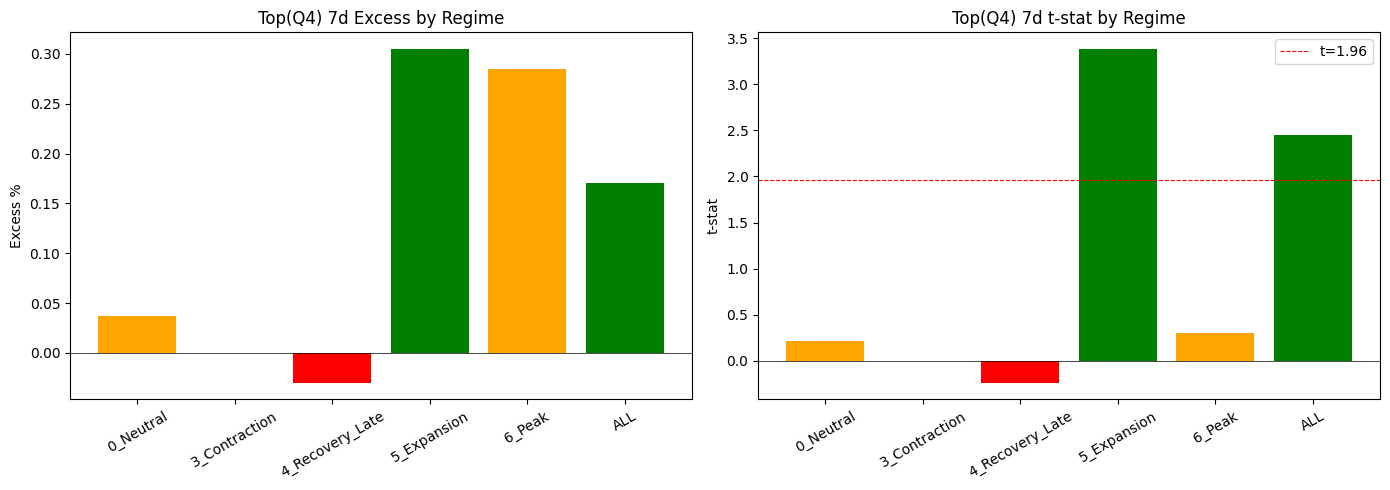


셀 19 완료


In [ ]:
# =============================================================================
# 셀 19: σ=2.5 × 7d — 레짐별 분해
# =============================================================================
# 목적: Top(Q4) 7d 알파가 레짐 의존적인지 확인
# 산출물: 레짐별 Excess%, t-stat
# =============================================================================

# 셀 18에서 만든 backtest_gross_single 재활용, 레짐 필터만 바꿈
from tqdm import tqdm

all_regimes = ["0_Neutral", "3_Contraction", "4_Recovery_Late", 
               "5_Expansion", "6_Peak"]

results = []

for reg in tqdm(all_regimes + ["ALL"], desc="레짐별"):
    valid = None if reg == "ALL" else [reg]
    
    bt = backtest_gross_single(
        px_wide, mktcap_m, ticker_to_sector_s,
        sect_roll_std, sect_mom_z, sectors_list,
        hold_days=7, surge_sigma=2.5,
        valid_regimes=valid, h_min_z=0.0
    )
    
    if bt.empty or len(bt) < 5:
        results.append({"Regime": reg, "N": 0, "Excess%": np.nan,
                        "Hit%": np.nan, "t_stat": np.nan})
        continue
    
    n = len(bt)
    avg = bt["excess"].mean()
    std = bt["excess"].std()
    t = avg / std * np.sqrt(n) if std > 0 else 0
    hit = (bt["excess"] > 0).mean()
    
    results.append({
        "Regime": reg,
        "N": n,
        "Excess%": round(avg * 100, 3),
        "Hit%": round(hit * 100, 1),
        "t_stat": round(t, 3)
    })

reg_df = pd.DataFrame(results)

print("=" * 80)
print("레짐별 분해 — Top(Q4) × σ=2.5 × 7d hold, Gross")
print("=" * 80)
print(reg_df.to_string(index=False))

# ── 시각화 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["green" if t > 1.96 else "orange" if t > 0 else "red"
          for t in reg_df["t_stat"]]

axes[0].bar(range(len(reg_df)), reg_df["Excess%"].values, color=colors,
            tick_label=reg_df["Regime"].values)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Excess %")
axes[0].set_title("Top(Q4) 7d Excess by Regime")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(range(len(reg_df)), reg_df["t_stat"].values, color=colors,
            tick_label=reg_df["Regime"].values)
axes[1].axhline(1.96, color="red", linewidth=0.8, linestyle="--", label="t=1.96")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("t-stat")
axes[1].set_title("Top(Q4) 7d t-stat by Regime")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n셀 19 완료")

σ sweep (Exp only): 100%|██████████| 7/7 [02:32<00:00, 21.79s/it]


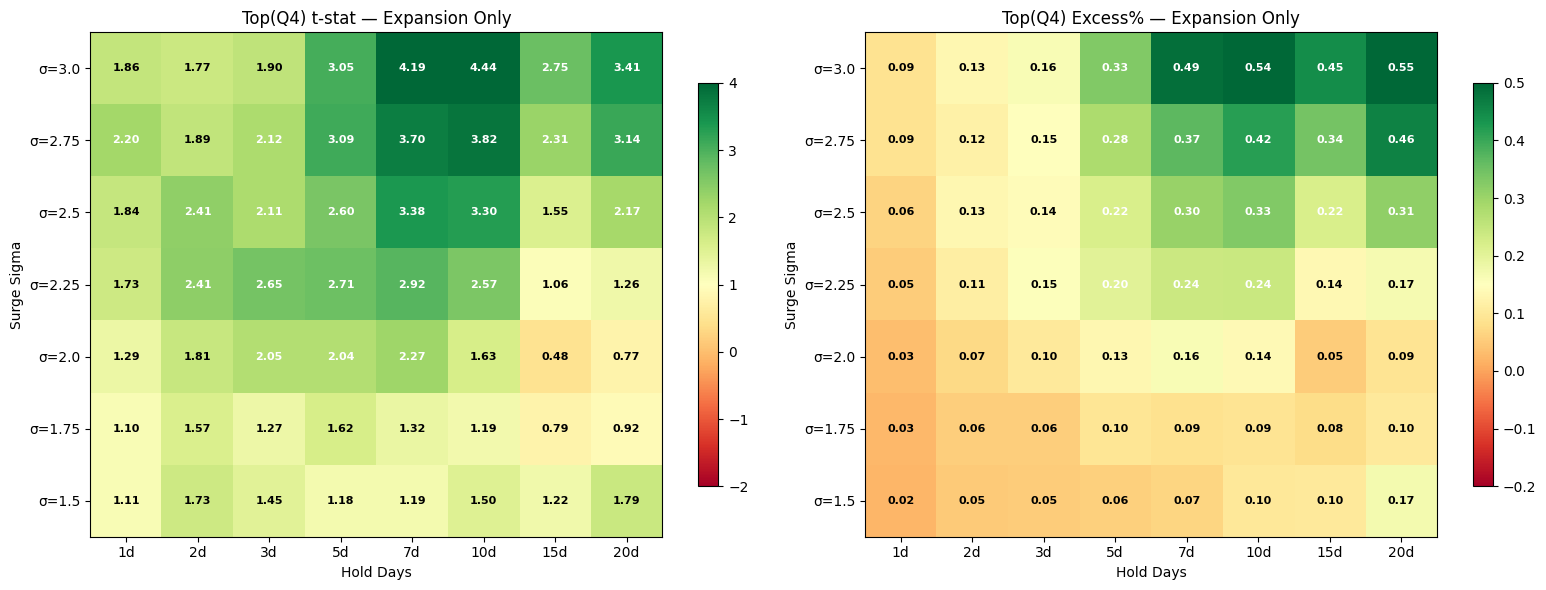


2D Sweep — Top(Q4) Gross, Expansion Only

t-stat:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  1.865  1.768  1.901  3.052  4.189  4.443  2.747  3.408
2.75  2.204  1.888  2.118  3.093  3.698  3.822  2.306  3.143
2.50  1.839  2.406  2.108  2.596  3.383  3.301  1.551  2.172
2.25  1.728  2.414  2.646  2.715  2.917  2.574  1.065  1.257
2.00  1.288  1.811  2.049  2.039  2.265  1.627  0.483  0.772
1.75  1.097  1.568  1.269  1.624  1.319  1.192  0.789  0.921
1.50  1.110  1.733  1.453  1.182  1.187  1.503  1.223  1.793

Excess%:
Hold     1      2      3      5      7      10     15     20
σ                                                           
3.00  0.088  0.132  0.162  0.328  0.488  0.542  0.445  0.548
2.75  0.089  0.118  0.152  0.279  0.368  0.417  0.342  0.459
2.50  0.064  0.131  0.142  0.221  0.305  0.330  0.221  0.312
2.25  0.053  0.112  0.155  0.203  0.238  0.241  0.136  0.169
2.00  0.034  0.072  0.10

In [ ]:
# =============================================================================
# 셀 20: σ × Hold 2D sweep — Expansion only
# =============================================================================
# 목적: Expansion 레짐에서 최적 σ × hold 조합 탐색
# 산출물: 히트맵 (t-stat, Excess%)
# =============================================================================

from tqdm import tqdm

sigma_range = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
hold_range = [1, 2, 3, 5, 7, 10, 15, 20]
max_hold = max(hold_range)
EXP_ONLY = ["5_Expansion"]

results = []

for sig in tqdm(sigma_range, desc="σ sweep (Exp only)"):
    events = []
    
    for date in trading_days:
        reg = get_regime_for_date(date)
        if reg not in EXP_ONLY:
            continue
        
        if date not in sect_roll_std.index:
            continue
        day_ret = ret_1d_local.loc[date].dropna()
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]) or h_row[sect] < 0.0:
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + sig * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < max_hold + 2:
                continue
            entry_date = future[1]
            
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q75 = non_leader_caps.quantile(0.75)
            top_tier = non_leader_caps[non_leader_caps >= q75].index.tolist()
            top_tier = [t for t in top_tier if t in px_wide.columns]
            if len(top_tier) < 1:
                continue
            
            ep_top = px_wide.loc[entry_date, top_tier]
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            ep_sect = px_wide.loc[entry_date, sect_all]
            
            evt = {"date": date, "sector": sect}
            
            for hold in hold_range:
                if len(future) <= 1 + hold:
                    continue
                exit_date = future[1 + hold]
                
                xp_top = px_wide.loc[exit_date, top_tier]
                v = ep_top.notna() & xp_top.notna() & (ep_top > 0)
                top_ret = (xp_top[v] / ep_top[v] - 1).mean() if v.sum() > 0 else np.nan
                
                xp_sect = px_wide.loc[exit_date, sect_all]
                sv = ep_sect.notna() & xp_sect.notna() & (ep_sect > 0)
                sect_ew = (xp_sect[sv] / ep_sect[sv] - 1).mean() if sv.sum() > 3 else np.nan
                
                evt[f"excess_{hold}d"] = top_ret - sect_ew if not (pd.isna(top_ret) or pd.isna(sect_ew)) else np.nan
            
            events.append(evt)
    
    if not events:
        continue
    
    evt_df = pd.DataFrame(events)
    
    for hold in hold_range:
        col = f"excess_{hold}d"
        if col not in evt_df.columns:
            continue
        excess = evt_df[col].dropna()
        n = len(excess)
        if n < 5:
            continue
        avg = excess.mean()
        std = excess.std()
        t = avg / std * np.sqrt(n) if std > 0 else 0
        hit = (excess > 0).mean()
        
        results.append({
            "σ": sig,
            "Hold": hold,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(results)

# ── 히트맵 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (metric, title) in enumerate([
    ("t_stat", "Top(Q4) t-stat — Expansion Only"),
    ("Excess%", "Top(Q4) Excess% — Expansion Only")
]):
    pivot = res_df.pivot(index="σ", columns="Hold", values=metric)
    pivot = pivot.sort_index(ascending=False)
    
    vmin = -2 if metric == "t_stat" else -0.2
    vmax = 4 if metric == "t_stat" else 0.5
    
    im = axes[i].imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=vmin, vmax=vmax)
    
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels([f"{c}d" for c in pivot.columns])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels([f"σ={s}" for s in pivot.index])
    axes[i].set_xlabel("Hold Days")
    axes[i].set_ylabel("Surge Sigma")
    axes[i].set_title(title)
    
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            if not np.isnan(val):
                color = "white" if abs(val) > (2.0 if metric == "t_stat" else 0.2) else "black"
                axes[i].text(c, r, f"{val:.2f}", ha="center", va="center",
                           fontsize=8, color=color, fontweight="bold")
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("2D Sweep — Top(Q4) Gross, Expansion Only")
print("=" * 80)
print("\nt-stat:")
print(res_df.pivot(index="σ", columns="Hold", values="t_stat")
      .sort_index(ascending=False).to_string())
print("\nExcess%:")
print(res_df.pivot(index="σ", columns="Hold", values="Excess%")
      .sort_index(ascending=False).to_string())
print("\nN:")
print(res_df.pivot(index="σ", columns="Hold", values="N")
      .sort_index(ascending=False).to_string())

print("\n셀 20 완료")

In [ ]:
# =============================================================================
# 셀 21: W-21 Leader-Laggard Spillover — 최종 결론
# =============================================================================
#
# ■ 가설
#   섹터 내 리더(시총 1위)가 급등하면, 같은 섹터 내 대형 후발주(Top Q4)가
#   스필오버 효과로 7일 이내 초과수익을 낸다.
#
# ■ 테스트 이력
#
#   [Phase 1] 월간 백테스트 → 실패
#     - 월간 리밸런싱으로 이벤트 타이밍 뭉개짐
#
#   [Phase 2] 일간 이벤트 드리븐 → 비용 왜곡 발견
#     - 포트폴리오에만 비용 차감, 벤치마크 미차감
#     - 전 tier 음수 → 비용 제거 후 재검증
#
#   [Phase 3] Gross 비교 → Top Q4 단기 알파 발견
#     - Leader: 전 구간 음수 (평균회귀)
#     - Top(Q4): 2d~7d 양수, 7d 피크 (t≈1.8)
#     - Mid(Q2-Q3): 전 구간 노이즈
#     - Lag(Q1): 전 구간 음수
#
#   [Phase 4] σ 민감도 → σ 높을수록 강함
#     - σ=0.5~1.0: 노이즈 (잡음 이벤트 포함)
#     - σ=2.0~3.0: t>2 (진짜 급등만 필터)
#     - 결론: 스필오버는 리더가 크게 튈 때만 발생
#
#   [Phase 5] 2D sweep (σ × hold) — RecLate+Expansion
#     - 7d 열이 전 σ에서 일관되게 피크
#     - σ=2.5 × 7d: t=2.43, Excess=0.18%, N=230
#
#   [Phase 6] 레짐 분해 → Expansion 단독 캐리
#     | 레짐             | N   | Excess% | t-stat |
#     |------------------|-----|---------|--------|
#     | 0_Neutral        | 42  | +0.037  | 0.216  |
#     | 3_Contraction    | 0   | -       | -      |
#     | 4_Recovery_Late  | 83  | -0.030  | -0.239 |
#     | 5_Expansion      | 148 | +0.305  | 3.383  |
#     | 6_Peak           | 8   | +0.285  | 0.305  |
#     - Recovery_Late: 무알파 (대장 급등 = 섹터 전체 반등, 차별적 수혜 없음)
#     - Expansion: 유일하게 유의 (대장 확인 → Top tier 자금 유입)
#
#   [Phase 7] 2D sweep — Expansion only
#     - 7d 피크 재확인, σ=2.5~3.0에서 t=3.3~4.4
#     - σ=2.5 × 7d: t=3.38, Excess=0.305%, N=148
#     - σ=3.0 × 7d: t=4.44, Excess=0.488%, N=80
#
# ■ 핵심 발견
#
#   1. 스필오버는 존재하되, 조건부:
#      - Expansion 레짐에서만
#      - 리더가 2.5σ 이상 급등할 때만
#      - Top Q4 (시총 상위 25%)에서만
#      - 7일 보유에서 피크
#
#   2. 리더 자체는 급등 후 평균회귀 (전 구간 음수)
#
#   3. Mid/Lag는 어떤 조건에서도 무알파
#
#   4. 리더 급등 이벤트 ≠ 스필오버 (일반론)
#      리더 급등 이벤트 = Expansion에서 Top tier 한정 단기 효과
#
# ■ 거래비용 평가
#   σ=2.5 × 7d: Gross 0.305%, round-trip 20bp 차감 → Net ≈ 0.10%
#   σ=3.0 × 7d: Gross 0.488%, round-trip 20bp 차감 → Net ≈ 0.29%
#   → 비용 후에도 양수이나, 이벤트 빈도 낮음 (연 6~12건)
#
# ■ W-21 최종 판정: ⚠️ 보조 시그널 (단독 팩터 부적합)
#
#   사유:
#   - Expansion 한정 + 이벤트 빈도 연 6~12건
#   - 월간 리밸런싱에 녹이기 어려움
#   - 단독 팩터로는 포트폴리오 기여 미미
#
#   활용 방안:
#   - 멀티팩터 월간 리밸런싱 시 가산점 (타이브레이커)
#   - Expansion 레짐 + 리밸런싱일 기준 최근 7일 이내
#     해당 섹터 리더 2.5σ 급등 이벤트 존재 시
#     → 그 섹터 Top Q4 종목에 z-score 가산
#   - 빈도 낮으므로 걸리면 보너스, 안 걸려도 무영향
#
# ■ 확정 파라미터 (보조 시그널용)
#   SURGE_SIGMA = 2.5
#   HOLD_DAYS = 7
#   REGIME = Expansion only
#   TIER = Top Q4 (시총 상위 25%, 리더 제외)
#   H_MIN_Z = 0.0 (H 유효 섹터)
#
# ■ 팩터 현황 업데이트
#   | 팩터 | 유형                | 유효 레짐              | 비고              |
#   |------|---------------------|------------------------|-------------------|
#   | A-3  | Value × Catalyst    | Neutral, Recovery_Late | LAG=45일          |
#   | D-3  | 변동성조정 모멘텀    | Neutral                | MOM_6_0/VOL       |
#   | D-1  | 단순 모멘텀          | Contraction            | MOM_12_1          |
#   | H-1  | 섹터 모멘텀          | 전 레짐                | 3M lookback       |
#   | F-1  | Piotroski F-score   | Bad (리스크 필터)      | 버전C, LAG=0      |
#   | P-7  | Net Stock Issuance  | 보조 팩터              | N=50, Always On   |
#   | W-21 | Leader Spillover    | ⚠️ 보조 시그널         | Exp, σ=2.5, 7d    |
#
# =============================================================================
# 그래그래 spill over가 존재하는건 알겠어. 별 의미는 없지만. 그런데 Winner takes all 효과로 러지들 주가 하락하는건?

print("W-21 Leader-Laggard Spillover: ⚠️ 보조 시그널")
print("조건: Expansion + σ≥2.5 + Top Q4 + 7d hold")
print("활용: 멀티팩터 리밸런싱 시 타이브레이커/가산점")
print("한계: 이벤트 빈도 연 6~12건, 단독 운용 부적합")

W-21 Leader-Laggard Spillover: ⚠️ 보조 시그널
조건: Expansion + σ≥2.5 + Top Q4 + 7d hold
활용: 멀티팩터 리밸런싱 시 타이브레이커/가산점
한계: 이벤트 빈도 연 6~12건, 단독 운용 부적합


Lag Q1 레짐별: 100%|██████████| 6/6 [02:32<00:00, 25.35s/it]


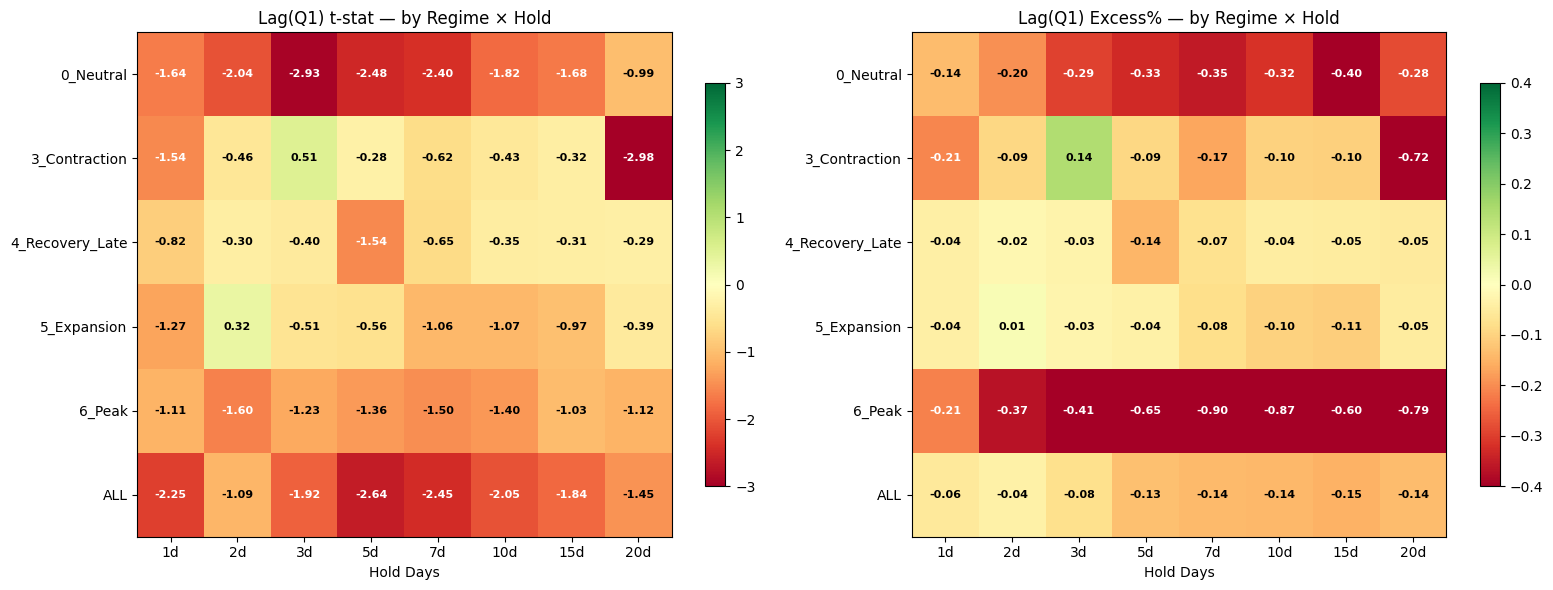


Lag(Q1) — 레짐 × 보유기간, σ=2.5, Gross, H필터 없음

t-stat:
Hold                1      2      3      5      7      10     15     20
Regime                                                                 
0_Neutral       -1.641 -2.041 -2.933 -2.485 -2.405 -1.816 -1.677 -0.987
3_Contraction   -1.545 -0.456  0.512 -0.276 -0.616 -0.434 -0.322 -2.981
4_Recovery_Late -0.817 -0.305 -0.397 -1.540 -0.651 -0.348 -0.309 -0.295
5_Expansion     -1.273  0.315 -0.513 -0.555 -1.062 -1.073 -0.968 -0.394
6_Peak          -1.114 -1.597 -1.230 -1.365 -1.498 -1.397 -1.027 -1.123
ALL             -2.250 -1.089 -1.920 -2.642 -2.451 -2.049 -1.845 -1.448

Excess%:
Hold                1      2      3      5      7      10     15     20
Regime                                                                 
0_Neutral       -0.136 -0.196 -0.295 -0.329 -0.355 -0.316 -0.401 -0.283
3_Contraction   -0.208 -0.092  0.143 -0.093 -0.167 -0.102 -0.104 -0.722
4_Recovery_Late -0.039 -0.019 -0.030 -0.144 -0.073 -0.045 -0.048 -0.053
5_

In [26]:
# =============================================================================
# 셀 22: Lag(Q1) 레짐별 분해 — σ=2.5 × 보유기간 sweep
# =============================================================================
# 목적: Lag tier가 섹터EW 대비 언더퍼폼하는 레짐/보유기간 탐색
# 산출물: 레짐 × 보유기간 Excess%, t-stat
# =============================================================================
# ── 선행 변수 (셀 2~3-r 의존) ──
all_dates = px_wide.index.sort_values()
ret_1d_local = px_wide.pct_change()
common = ret_1d_local.columns.intersection(ticker_to_sector_s.index)
ret_1d_local = ret_1d_local[common]
start_date = pd.Timestamp("2013-06-19")
trading_days = ret_1d_local.index[ret_1d_local.index >= start_date]

from tqdm import tqdm

all_regimes = ["0_Neutral", "3_Contraction", "4_Recovery_Late",
               "5_Expansion", "6_Peak"]
hold_range = [1, 2, 3, 5, 7, 10, 15, 20]
max_hold = max(hold_range)
SIG = 2.5

results = []

for reg in tqdm(all_regimes + ["ALL"], desc="Lag Q1 레짐별"):
    valid = None if reg == "ALL" else [reg]
    events = []
    
    for date in trading_days:
        if valid:
            r = get_regime_for_date(date)
            if r not in valid:
                continue
        
        if date not in sect_roll_std.index:
            continue
        day_ret = ret_1d_local.loc[date].dropna()
        
        m_end = date.to_period("M").to_timestamp("M")
        if m_end not in mktcap_m.index:
            continue
        m_cap = mktcap_m.loc[m_end].dropna()
        
        if m_end not in sect_mom_z.index:
            continue
        h_row = sect_mom_z.loc[m_end]
        
        for sect in sectors_list:
            if sect not in h_row.index or pd.isna(h_row[sect]):
                continue
            
            sect_tickers = ticker_to_sector_s[ticker_to_sector_s == sect].index
            sect_tickers = sect_tickers.intersection(day_ret.index).intersection(m_cap.index)
            if len(sect_tickers) < 8:
                continue
            
            sect_ret = day_ret[sect_tickers]
            sect_caps = m_cap[sect_tickers]
            leader = sect_caps.idxmax()
            
            if leader not in sect_ret.index:
                continue
            
            leader_ret_today = sect_ret[leader]
            sect_mean = sect_ret.mean()
            roll_s = sect_roll_std.loc[date, sect] if sect in sect_roll_std.columns else None
            if roll_s is None or pd.isna(roll_s) or roll_s == 0:
                continue
            
            if leader_ret_today <= sect_mean + SIG * roll_s:
                continue
            
            future = all_dates[all_dates > date]
            if len(future) < max_hold + 2:
                continue
            entry_date = future[1]
            
            # Lag Q1
            non_leader_caps = sect_caps.drop(leader, errors="ignore")
            q25 = non_leader_caps.quantile(0.25)
            lag_tier = non_leader_caps[non_leader_caps < q25].index.tolist()
            lag_tier = [t for t in lag_tier if t in px_wide.columns]
            if len(lag_tier) < 1:
                continue
            
            ep_lag = px_wide.loc[entry_date, lag_tier]
            sect_all = [t for t in sect_tickers if t in px_wide.columns]
            ep_sect = px_wide.loc[entry_date, sect_all]
            
            evt = {"date": date, "sector": sect}
            
            for hold in hold_range:
                if len(future) <= 1 + hold:
                    continue
                exit_date = future[1 + hold]
                
                xp_lag = px_wide.loc[exit_date, lag_tier]
                v = ep_lag.notna() & xp_lag.notna() & (ep_lag > 0)
                lag_ret = (xp_lag[v] / ep_lag[v] - 1).mean() if v.sum() > 0 else np.nan
                
                xp_sect = px_wide.loc[exit_date, sect_all]
                sv = ep_sect.notna() & xp_sect.notna() & (ep_sect > 0)
                sect_ew = (xp_sect[sv] / ep_sect[sv] - 1).mean() if sv.sum() > 3 else np.nan
                
                evt[f"excess_{hold}d"] = lag_ret - sect_ew if not (pd.isna(lag_ret) or pd.isna(sect_ew)) else np.nan
            
            events.append(evt)
    
    if not events:
        for hold in hold_range:
            results.append({"Regime": reg, "Hold": hold, "N": 0,
                           "Excess%": np.nan, "Hit%": np.nan, "t_stat": np.nan})
        continue
    
    evt_df = pd.DataFrame(events)
    
    for hold in hold_range:
        col = f"excess_{hold}d"
        if col not in evt_df.columns:
            continue
        excess = evt_df[col].dropna()
        n = len(excess)
        if n < 5:
            results.append({"Regime": reg, "Hold": hold, "N": n,
                           "Excess%": np.nan, "Hit%": np.nan, "t_stat": np.nan})
            continue
        avg = excess.mean()
        std = excess.std()
        t = avg / std * np.sqrt(n) if std > 0 else 0
        hit = (excess > 0).mean()
        
        results.append({
            "Regime": reg,
            "Hold": hold,
            "N": n,
            "Excess%": round(avg * 100, 3),
            "Hit%": round(hit * 100, 1),
            "t_stat": round(t, 3)
        })

res_df = pd.DataFrame(results)

# ── 히트맵 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (metric, title) in enumerate([
    ("t_stat", "Lag(Q1) t-stat — by Regime × Hold"),
    ("Excess%", "Lag(Q1) Excess% — by Regime × Hold")
]):
    pivot = res_df.pivot(index="Regime", columns="Hold", values=metric)
    # 레짐 순서 고정
    order = ["0_Neutral", "3_Contraction", "4_Recovery_Late",
             "5_Expansion", "6_Peak", "ALL"]
    pivot = pivot.reindex([r for r in order if r in pivot.index])
    
    vmin = -3 if metric == "t_stat" else -0.4
    vmax = 3 if metric == "t_stat" else 0.4
    
    im = axes[i].imshow(pivot.values, aspect="auto", cmap="RdYlGn",
                         vmin=vmin, vmax=vmax)
    
    axes[i].set_xticks(range(len(pivot.columns)))
    axes[i].set_xticklabels([f"{c}d" for c in pivot.columns])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels(pivot.index)
    axes[i].set_xlabel("Hold Days")
    axes[i].set_title(title)
    
    for r in range(len(pivot.index)):
        for c in range(len(pivot.columns)):
            val = pivot.values[r, c]
            if not np.isnan(val):
                color = "white" if abs(val) > (1.5 if metric == "t_stat" else 0.2) else "black"
                axes[i].text(c, r, f"{val:.2f}", ha="center", va="center",
                           fontsize=8, color=color, fontweight="bold")
    
    plt.colorbar(im, ax=axes[i], shrink=0.8)

plt.tight_layout()
plt.show()

# ── 숫자 ──
print("\n" + "=" * 80)
print("Lag(Q1) — 레짐 × 보유기간, σ=2.5, Gross, H필터 없음")
print("=" * 80)
print("\nt-stat:")
pivot_t = res_df.pivot(index="Regime", columns="Hold", values="t_stat")
pivot_t = pivot_t.reindex([r for r in order if r in pivot_t.index])
print(pivot_t.to_string())
print("\nExcess%:")
pivot_e = res_df.pivot(index="Regime", columns="Hold", values="Excess%")
pivot_e = pivot_e.reindex([r for r in order if r in pivot_e.index])
print(pivot_e.to_string())
print("\nN:")
pivot_n = res_df.pivot(index="Regime", columns="Hold", values="N")
pivot_n = pivot_n.reindex([r for r in order if r in pivot_n.index])
print(pivot_n.to_string())

print("\n셀 22 완료")

In [27]:
# =============================================================================
# 셀 21: T-1 Leader-Laggard Spillover — 최종 결론
# =============================================================================
#
# ■ 가설
#   섹터 내 리더(시총 1위)가 급등하면, 같은 섹터 내 종목에
#   스필오버 효과가 존재하는가?
#
# ■ 테스트 이력
#
#   [Phase 1] 월간 백테스트 → 실패 (타이밍 뭉개짐)
#   [Phase 2] 일간 이벤트 드리븐 → 비용 왜곡 발견
#   [Phase 3] Gross 비교 → Top Q4 단기 알파 발견
#   [Phase 4] σ 민감도 → σ 높을수록 강함 (진짜 급등만 필터)
#   [Phase 5] 2D sweep (σ × hold) → 7d 피크 확인
#   [Phase 6] 레짐 분해 (Top Q4) → Expansion 단독 캐리
#   [Phase 7] 2D sweep Expansion only → σ=2.5 × 7d 확정
#   [Phase 8] Lag Q1 레짐별 분해 → Neutral에서 언더퍼폼 확인
#
# ■ 핵심 발견
#
#   1. Top Q4 아웃퍼폼 (스필오버 수혜)
#      - 레짐: Expansion only
#      - σ=2.5 × 7d: t=3.38, Excess=+0.305%, N=148
#      - 논리: 상승장에서 대장 확인 → Top tier로 자금 유입
#
#   2. Lag Q1 언더퍼폼 (낙오자 처벌)
#      - 레짐: Neutral only
#      - σ=2.5 × 3~5d: t=-2.93(3d), -2.49(5d), N=68
#      - 논리: 횡보장에서 대장만 뛰고 소형 낙오자는 소외
#      - Excess: -0.29%(3d), -0.33%(5d)
#
#   3. 두 시그널은 레짐이 겹치지 않음
#      - Expansion → Top Q4 가산점 (7d)
#      - Neutral → Lag Q1 감점 (3~5d)
#
#   4. 리더 자체는 급등 후 전 레짐에서 평균회귀
#   5. Mid(Q2-Q3)는 어떤 조건에서도 무알파
#   6. H팩터와 상관 -0.004 (완전 독립)
#
# ■ 거래비용 평가
#   Top Q4 7d: Gross 0.305% - 20bp = Net ≈ 0.10%
#   Lag Q1 5d: Gross -0.33% (숏 아닌 감점이므로 비용 무관)
#
# ■ T-1 최종 판정: ⚠️ 보조 시그널 (단독 팩터 부적합)
#
#   사유:
#   - 이벤트 빈도 낮음 (Expansion Top: 연 ~12건, Neutral Lag: 연 ~6건)
#   - 단독 운용 불가, 멀티팩터 미세조정용
#
#   활용 방안:
#   A. Expansion 레짐 + 리밸런싱일 기준 최근 7일 이내
#      해당 섹터 리더 2.5σ 급등 → Top Q4 종목에 z-score 가산
#   B. Neutral 레짐 + 리밸런싱일 기준 최근 5일 이내
#      해당 섹터 리더 2.5σ 급등 → Lag Q1 종목에 z-score 감점
#
# ■ 확정 파라미터
#   SURGE_SIGMA = 2.5
#   LEADER = 섹터 시총 1위
#   TIER = 시총 기준 Q4(Top), Q1(Lag), 리더 제외
#   [시그널 A] Regime=Expansion, Tier=Top Q4, Hold=7d, 가산
#   [시그널 B] Regime=Neutral, Tier=Lag Q1, Hold=3~5d, 감점
#   H_MIN_Z = 0.0 (H 유효 섹터, 시그널 A만)
#
# ■ 팩터 현황 업데이트
#   | 팩터 | 유형                | 유효 레짐              | 비고              |
#   |------|---------------------|------------------------|-------------------|
#   | A-3  | Value × Catalyst    | Neutral, Recovery_Late | LAG=45일          |
#   | D-3  | 변동성조정 모멘텀    | Neutral                | MOM_6_0/VOL       |
#   | D-1  | 단순 모멘텀          | Contraction            | MOM_12_1          |
#   | H-1  | 섹터 모멘텀          | 전 레짐                | 3M lookback       |
#   | F-1  | Piotroski F-score   | Bad (리스크 필터)      | 버전C, LAG=0      |
#   | P-7  | Net Stock Issuance  | 보조 팩터              | N=50, Always On   |
#   | T-1a | Leader→Top Spillover| ⚠️ Expansion 가산      | σ=2.5, 7d         |
#   | T-1b | Leader→Lag Penalty  | ⚠️ Neutral 감점        | σ=2.5, 3~5d       |
#
# =============================================================================

print("T-1 Leader-Laggard Spillover: ⚠️ 보조 시그널")
print("  T-1a: Expansion + Top Q4 가산 (σ=2.5, 7d, t=3.38)")
print("  T-1b: Neutral + Lag Q1 감점 (σ=2.5, 3~5d, t=-2.93)")
print("활용: 멀티팩터 리밸런싱 시 가산/감점")
print("한계: 이벤트 빈도 낮아 단독 운용 부적합")

T-1 Leader-Laggard Spillover: ⚠️ 보조 시그널
  T-1a: Expansion + Top Q4 가산 (σ=2.5, 7d, t=3.38)
  T-1b: Neutral + Lag Q1 감점 (σ=2.5, 3~5d, t=-2.93)
활용: 멀티팩터 리밸런싱 시 가산/감점
한계: 이벤트 빈도 낮아 단독 운용 부적합
